# O mercado de trabalho formal em Uberlândia (CAGED 2025)

Terceiro projeto do portfólio, e o mais pessoal: uso dados para responder o que todo mundo que procura emprego quer saber. Quem está contratando na cidade, em quais setores, e pagando quanto?

**Fonte dos dados:** microdados do Novo CAGED (Cadastro Geral de Empregados e Desempregados), do Ministério do Trabalho e Emprego. Cada linha é uma admissão ou um desligamento de emprego formal declarado pelas empresas. Baixei os 12 meses de 2025 e filtrei só Uberlândia (código 317020).

Links oficiais:

- [Microdados do Novo CAGED](https://www.gov.br/trabalho-e-emprego/pt-br/acesso-a-informacao/acoes-e-programas/programas-projetos-acoes-obras-e-atividades/estatisticas-trabalho/microdados-rais-e-caged)

## Uma limitação importante

O CAGED cobre só **emprego formal** (com carteira assinada). Trabalho informal, autônomo e bico ficam de fora. E o dado mostra movimentação, não estoque: mostra quem entrou e quem saiu no ano.

## 1. Setup

In [1]:
import glob
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

import os
os.makedirs('graficos', exist_ok=True)
print('ok')

ok


## 2. Carregar os dados

O arquivo `dados/uberlandia_caged_2025.csv` já está filtrado para a cidade. Quem quiser refazer a partir do zero: o passo a passo do download e do filtro está no README da pasta (os arquivos originais do CAGED têm o Brasil inteiro, mais de 400 MB por mês).

In [2]:
mov = pd.read_csv('dados/uberlandia_caged_2025.csv', dtype={'município': str})
mov['saldomovimentação'] = pd.to_numeric(mov['saldomovimentação'])
mov['valorsaláriofixo'] = pd.to_numeric(mov['valorsaláriofixo'].astype(str).str.replace(',', '.', regex=False), errors='coerce')
mov['mes'] = mov['competênciamov'].astype(str).str[-2:].astype(int)

mov['tipo'] = mov['saldomovimentação'].map({1: 'admissão', -1: 'desligamento'})
print(f"{len(mov):,} movimentações em 2025".replace(',', '.'))
print(mov['tipo'].value_counts().to_string())
mov.head(3)

291.878 movimentações em 2025
tipo
admissão        146834
desligamento    145044


,competênciamov,região,uf,município,seção,subclasse,saldomovimentação,cbo2002ocupação,categoria,graudeinstrução,...,salário,tamestabjan,indicadoraprendiz,origemdainformação,competênciadec,indicadordeforadoprazo,unidadesaláriocódigo,valorsaláriofixo,mes,tipo
0,202501,3,31,317020,H,4930201,1,782510,101,7,...,"2664,01",5,0,1,202501,0,5,2664.01,1,admissão
1,202501,3,31,317020,C,2013402,-1,354135,101,9,...,"4214,00",4,0,1,202501,0,5,4214.00,1,desligamento
2,202501,3,31,317020,N,7723300,-1,516345,101,7,...,"1718,94",6,0,1,202501,0,5,1718.94,1,desligamento


## 3. Saldo do ano, mês a mês

Saldo = admissões menos desligamentos. Barra verde: mês que criou vagas. Vermelha: mês que fechou.

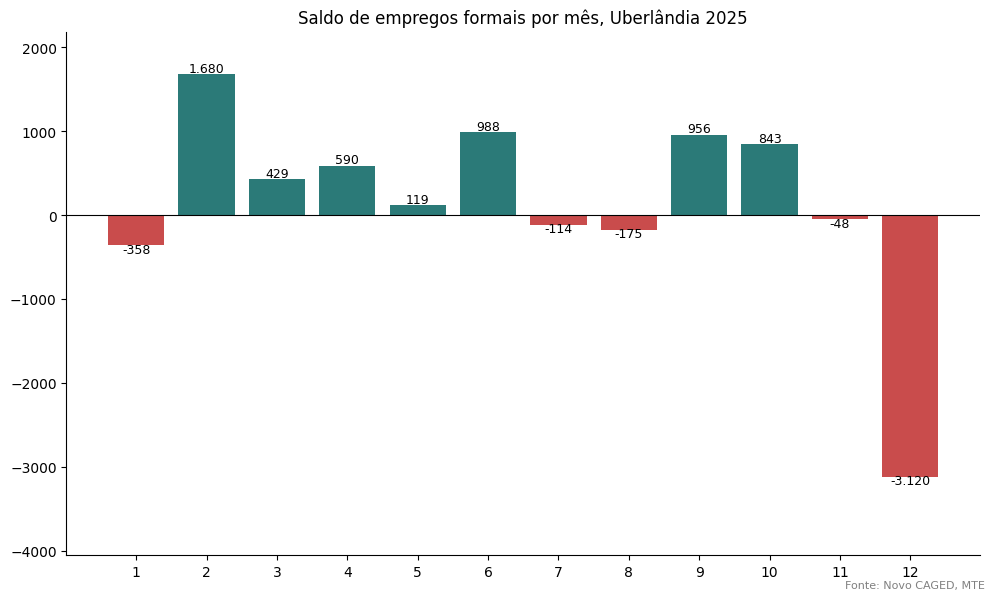

saldo do ano: 1.790 vagas


In [3]:
saldo_mes = mov.groupby('mes')['saldomovimentação'].sum()
cores = ['#2b7a78' if v > 0 else '#c94c4c' for v in saldo_mes]

fig, ax = plt.subplots()
barras = ax.bar(saldo_mes.index.astype(str), saldo_mes.values, color=cores)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_title('Saldo de empregos formais por mês, Uberlândia 2025')
for b, v in zip(barras, saldo_mes.values):
    ax.text(b.get_x() + b.get_width()/2, v + (30 if v > 0 else -90), f'{v:,.0f}'.replace(',', '.'),
            ha='center', fontsize=9)
ax.set_ylim(saldo_mes.min() * 1.3, saldo_mes.max() * 1.3)
fig.text(0.99, 0.01, 'Fonte: Novo CAGED, MTE', ha='right', fontsize=8, color='gray')
plt.tight_layout()
plt.savefig('graficos/saldo_mensal.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'saldo do ano: {saldo_mes.sum():,.0f} vagas'.replace(',', '.'))

## 4. Quais setores mais criaram vagas

Uso a seção da CNAE, a classificação oficial de atividade econômica.

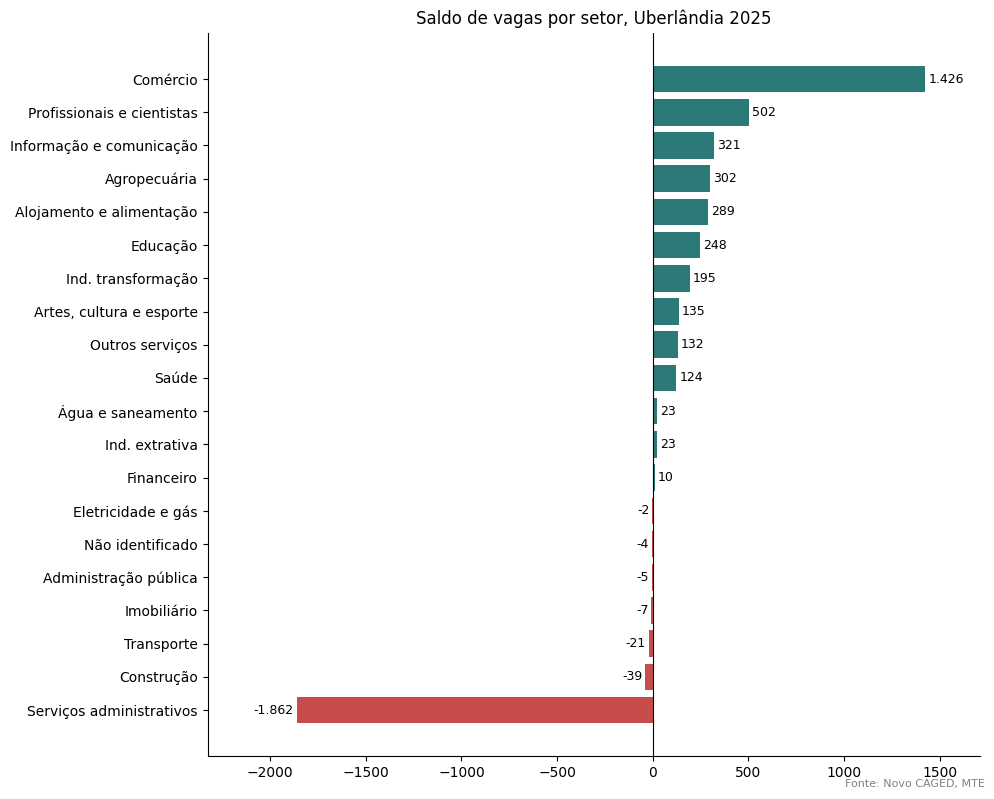

In [4]:
secoes = {
    'A': 'Agropecuária', 'B': 'Ind. extrativa', 'C': 'Ind. transformação',
    'D': 'Eletricidade e gás', 'E': 'Água e saneamento', 'F': 'Construção',
    'G': 'Comércio', 'H': 'Transporte', 'I': 'Alojamento e alimentação',
    'J': 'Informação e comunicação', 'K': 'Financeiro', 'L': 'Imobiliário',
    'M': 'Profissionais e cientistas', 'N': 'Serviços administrativos',
    'O': 'Administração pública', 'P': 'Educação', 'Q': 'Saúde',
    'R': 'Artes, cultura e esporte', 'S': 'Outros serviços',
    'T': 'Serviço doméstico', 'U': 'Organismos internacionais', 'Z': 'Não identificado',
}
mov['setor'] = mov['seção'].map(secoes).fillna(mov['seção'])

saldo_setor = mov.groupby('setor')['saldomovimentação'].sum().sort_values()
saldo_setor = saldo_setor[saldo_setor != 0]

fig, ax = plt.subplots(figsize=(10, 8))
cores = ['#2b7a78' if v > 0 else '#c94c4c' for v in saldo_setor]
ax.barh(saldo_setor.index, saldo_setor.values, color=cores)
ax.set_xlim(saldo_setor.min() * 1.25, saldo_setor.max() * 1.2)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Saldo de vagas por setor, Uberlândia 2025')
for i, v in enumerate(saldo_setor.values):
    ax.text(v + (15 if v > 0 else -15), i, f'{v:,.0f}'.replace(',', '.'),
            va='center', ha='left' if v > 0 else 'right', fontsize=9)
fig.text(0.99, 0.01, 'Fonte: Novo CAGED, MTE', ha='right', fontsize=8, color='gray')
plt.tight_layout()
plt.savefig('graficos/saldo_por_setor.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Quanto pagam os setores

Salário médio das **admissões** (valor do salário fixo mensal declarado no CAGED). Filtro os 10 setores com mais admissões para não distorcer com setores minúsculos.

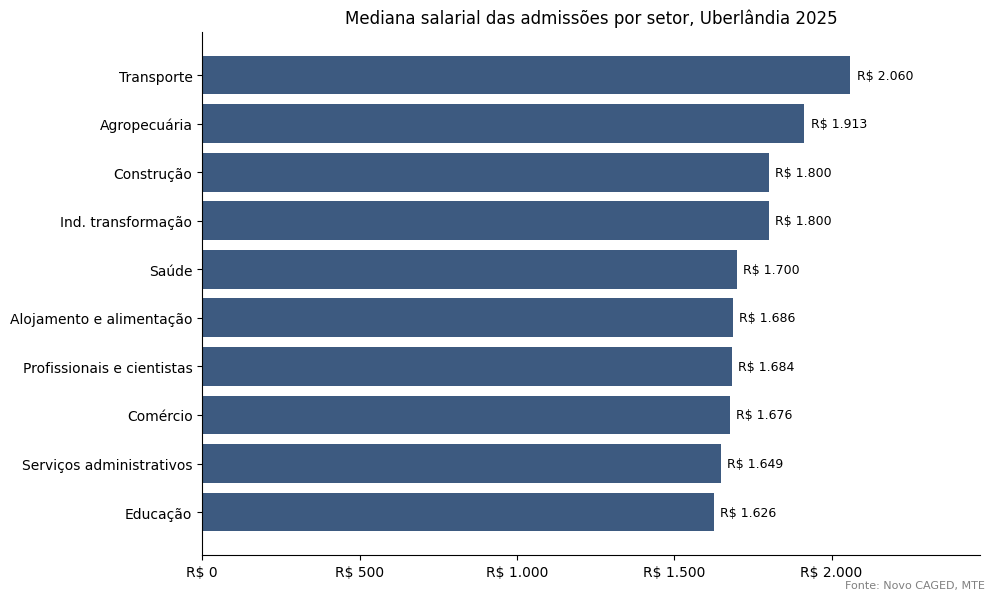

mediana salarial das admissões na cidade: R$ 1.724


In [5]:
adm = mov[(mov['tipo'] == 'admissão') & (mov['valorsaláriofixo'] > 0) & (mov['valorsaláriofixo'] < 100_000)]
top_setores = adm['setor'].value_counts().head(10).index
salario_setor = adm[adm['setor'].isin(top_setores)].groupby('setor')['valorsaláriofixo'].median().sort_values()

fig, ax = plt.subplots()
ax.barh(salario_setor.index, salario_setor.values, color='#3d5a80')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'R$ {v:,.0f}'.replace(',', '.')))
ax.set_title('Mediana salarial das admissões por setor, Uberlândia 2025')
for i, v in enumerate(salario_setor.values):
    ax.text(v + 20, i, f'R$ {v:,.0f}'.replace(',', '.'), va='center', fontsize=9)
ax.set_xlim(0, salario_setor.max() * 1.2)
fig.text(0.99, 0.01, 'Fonte: Novo CAGED, MTE', ha='right', fontsize=8, color='gray')
plt.tight_layout()
plt.savefig('graficos/salario_por_setor.png', dpi=150, bbox_inches='tight')
plt.show()

mediana_geral = adm['valorsaláriofixo'].median()
print(f'mediana salarial das admissões na cidade: R$ {mediana_geral:,.0f}'.replace(',', '.'))

## 6. Perfil de quem foi contratado

Escolaridade das admissões no ano. Os códigos do CAGED: 1 analfabeto, 2 a 5 fundamental, 6 médio incompleto, 7 médio completo, 8 superior incompleto, 9 superior completo, 10 mestrado, 11 doutorado, 80 pós-graduação.

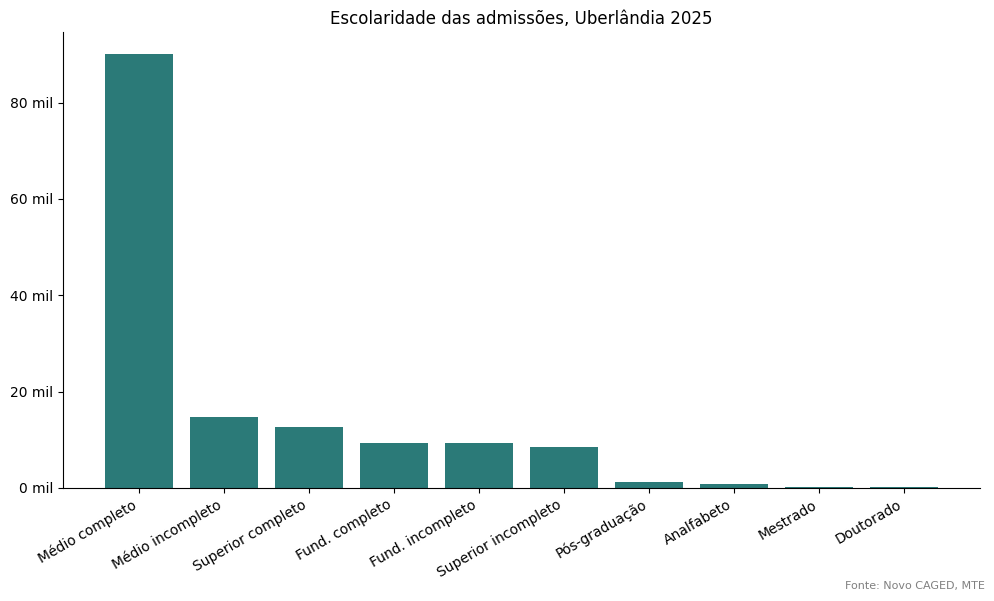

In [6]:
escolaridade = {
    1: 'Analfabeto', 2: 'Fund. incompleto', 3: 'Fund. incompleto',
    4: 'Fund. incompleto', 5: 'Fund. completo', 6: 'Médio incompleto',
    7: 'Médio completo', 8: 'Superior incompleto', 9: 'Superior completo',
    10: 'Mestrado', 11: 'Doutorado', 80: 'Pós-graduação', 99: 'Não identificado',
}
adm2 = mov[mov['tipo'] == 'admissão'].copy()
adm2['escolaridade'] = pd.to_numeric(adm2['graudeinstrução'], errors='coerce').map(escolaridade)
perfil = adm2['escolaridade'].value_counts()

fig, ax = plt.subplots()
ax.bar(perfil.index, perfil.values, color='#2b7a78')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v/1000:.0f} mil'))
ax.set_title('Escolaridade das admissões, Uberlândia 2025')
plt.xticks(rotation=30, ha='right')
fig.text(0.99, 0.01, 'Fonte: Novo CAGED, MTE', ha='right', fontsize=8, color='gray')
plt.tight_layout()
plt.savefig('graficos/escolaridade_admissoes.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. O que eu tiro disso

Uberlândia terminou 2025 com saldo de **1.790 vagas formais a mais** (146.834 admissões contra 145.044 desligamentos). Saldo positivo, mas apertado: de cada 100 vagas abertas, 99 fecharam no mesmo ano.

Três coisas me chamaram atenção:

1. **O ano começa e termina mal.** Janeiro fechou 358 vagas e dezembro fechou 3.120, o pior mês do ano. O miolo do ano carrega o resultado: fevereiro sozinho abriu 1.680 vagas.
2. **Comércio puxa para cima, serviços administrativos puxam para baixo.** O comércio criou 1.426 vagas líquidas, de longe o maior saldo. Do outro lado, serviços administrativos (limpeza, vigilância, telemarketing e afins) fecharam 1.862.
3. **O salário de entrada é baixo.** A mediana das admissões foi de R$ 1.724 por mês, pouco acima do salário mínimo de 2025 (R$ 1.518). Entre os setores que mais contratam, o melhor pago é transporte (R$ 2.060) e o pior é educação (R$ 1.626).

E tem o perfil de quem entra: 61% das admissões foram de pessoas com ensino médio completo e só 8,6% com superior completo. O mercado formal da cidade segue concentrado em vagas de escolaridade média e salário baixo.

Ressalvas importantes: o CAGED cobre só emprego com carteira assinada (informal e autônomo ficam de fora), o salário é o valor declarado na contratação (não acompanha aumentos) e uma mesma pessoa contratada e demitida no ano entra duas vezes na conta.